<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/4_parciales/2_parcial/2_parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/linear_algebra/blob/main/4_parciales/2_parcial/2_parcial.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

[Video de apoyo a la preparación de este parcial]()

# Retroalimentación del segundo parcial de Álgebra lineal sobre 

1. Espacios vectoriales (Módulo 1)
2. Subespacios Vectoriales (Módulo 2)
3. Combinación lineal y espacio generado (Módulo 3)
4. Independencia y dependencia lineal (Módulo 4)
5. Base y Dimensión 
6. SubEspacios asociados a una matriz     

# Retroalimentación módulo 1. Espacios Vectoriales. 

# Retroalimentación módulo 2. Subespacios Vectoriales.   

# Retroalimentación módulo 3. Combinación Lineal, Conjunto Generador y Espacio Generado.   

In [ ]:
import numpy as np

def genera_r2(vectores):
    """
    Determina si un conjunto de vectores (nd-arrays) genera R^2.
    
    Argumentos:
    vectores -- Una lista o set de arrays de numpy de forma (2,)
    
    Retorna:
    True si el conjunto genera R^2, False de lo contrario.
    """
    # 1. Convertir el conjunto de vectores en una matriz de (n, 2)
    # Cada vector será una fila de la matriz
    matriz = np.array(list(vectores))
    
    # 2. Un conjunto no puede generar R^2 si tiene menos de 2 vectores
    if matriz.shape[0] < 2:
        return False
    
    # 3. Calcular el rango de la matriz
    # El rango indica el número de dimensiones linealmente independientes
    rango = np.linalg.matrix_rank(matriz)
    
    return rango == 2


In [ ]:

# --- Ejemplos de uso ---
v1 = np.array([1, 3])
v2 = np.array([-2, 0])

conjunto_generador = {tuple(v1)}
# Nota: Usamos tuple porque los nd-arrays no son hashables y no pueden ir en un set directo.

print(f"¿Genera R^2?: {genera_r2(conjunto_generador)}") 


# Retroalimentación módulo 4. Dependencia e independencia Lineal.   

# Retroalimentación Módulo 5. Base y Dimensión de Espacios Vectoriales.   

¡Claro que sí! Para resolver esto con elegancia y precisión, la librería **SymPy** es la herramienta ideal, ya que permite trabajar con aritmética exacta (fracciones y números enteros) en lugar de aproximaciones decimales.

Aquí tienes una función diseñada para recibir una lista de listas (o una matriz de SymPy) y devolver los vectores que conforman la base del espacio nulo (el espacio solución del sistema $A\mathbf{x} = \mathbf{0}$).

---

## Función en Python con SymPy

```python


In [3]:
import sympy

def obtener_base_espacio_nulo(matriz_coeficientes):
    """
    Determina una base para el espacio solución de un sistema homogéneo.
    
    Argumentos:
    matriz_coeficientes: Puede ser una lista de listas o una matriz de SymPy.
    
    Retorna:
    Una lista de vectores (matrices columna) que forman la base con 
    componentes en formato racional (exacto).
    """
    # Convertimos la entrada a una instancia de Matrix de SymPy
    A = sympy.Matrix(matriz_coeficientes)
    
    # El método nullspace() de SymPy encuentra el "kernel" o espacio nulo.
    # Por defecto, SymPy utiliza el método de Gauss-Jordan manteniendo
    # los valores como objetos de la clase 'Rational' (fracciones).
    base = A.nullspace()
    
    return base


In [4]:

# --- Ejemplo de uso ---
# Definimos una matriz de coeficientes (sistema de 2x4)
# x + 2y + 0z + 3w = 0
# 0x + 0y + 1z + 4w = 0
datos = [
    [-1, 3, -2],
    [-3, 9, -6], 
    [2, -6, 4]
]

base_solucion = obtener_base_espacio_nulo(datos)

print(f"Se encontraron {len(base_solucion)} vectores en la base:\n")
for i, v in enumerate(base_solucion):
    print(f"Vector {i+1}:")
    sympy.pprint(v) # pprint muestra la fracción de forma visual
    print()


Se encontraron 2 vectores en la base:

Vector 1:
⎡3⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

Vector 2:
⎡-2⎤
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣1 ⎦



## ¿Por qué usar este enfoque?



* **Precisión Racional:** A diferencia de librerías como NumPy, que usan punto flotante ($0.33333333$), SymPy utiliza la clase `Rational`. Si el resultado es un tercio, verás literalmente `1/3`.
* **Método `nullspace()`:** Esta función de SymPy implementa automáticamente el proceso de llevar la matriz a su forma escalonada reducida por renglones (RREF) y despejar las variables libres para obtener los vectores paramétricos.
* **Manejo de Enteros:** Si prefieres que los vectores no tengan fracciones, puedes multiplicar cada vector resultante por el **mínimo común múltiplo** de sus denominadores, aunque matemáticamente, la base fraccionaria que entrega SymPy ya es totalmente válida y simplificada.



### Ejemplo de Salida
Si corres el código anterior, verás algo como esto:

> **Vector 1:**
> $\begin{bmatrix}-2\\1\\0\\0\end{bmatrix}$
>
> **Vector 2:**
> $\begin{bmatrix}-3\\0\\-4\\1\end{bmatrix}$



**Nota:** Si el sistema solo tiene la solución trivial ($\mathbf{x} = \mathbf{0}$), la función devolverá una lista vacía, lo cual es correcto ya que la dimensión del espacio solución sería 0.

# Retroalimentación módulo 6. Subespacios Vectoriales Asociados a una Matriz  

Para resolver este problema, SymPy es la herramienta perfecta porque permite trabajar con la **forma escalonada reducida por renglones (RREF)** manteniendo la precisión simbólica (fracciones exactas).

En un sistema de ecuaciones lineales $A\mathbf{x} = \mathbf{b}$, el vector $\mathbf{b}$ es una combinación lineal de las columnas de $A$ **si y solo si el sistema es consistente**. Los coeficientes de esa combinación son, precisamente, los componentes de la solución $\mathbf{x}$.

Aquí tienes el script con la función detallada:

---

## Script de Python con SymPy

```python


In [12]:
import sympy

def analizar_sistema_y_combinacion(matriz_aumentada_lista):
    """
    Determina si b es combinación lineal de las columnas de A.
    Usa el Teorema de Rouché-Frobenius para consistencia.
    """
    # 1. Convertimos a matriz de SymPy
    M_aug = sympy.Matrix(matriz_aumentada_lista)
    
    # 2. Separamos A (coeficientes) y b (vector columna)
    A = M_aug[:, :-1]
    b = M_aug[:, -1]
    
    # 3. Verificamos consistencia mediante rangos
    rango_A = A.rank()
    rango_aug = M_aug.rank()
    
    print("--- Análisis del Sistema ---")
    print(f"Rango de A: {rango_A}")
    print(f"Rango de [A|b]: {rango_aug}")
    
    if rango_A != rango_aug:
        print("\nResultado: El sistema es INCONSISTENTE.")
        print("El vector 'b' NO es una combinación lineal de las columnas de A.")
        return None
    
    print("\nResultado: El sistema es CONSISTENTE.")
    print("El vector 'b' SÍ es una combinación lineal de las columnas de A.")
    
    # 4. Resolvemos Ax = b
    # gauss_jordan_solve devuelve (solución particular, variables libres)
    solucion_particular, params = A.gauss_jordan_solve(b)
    
    # Si hay variables libres, ponemos sus parámetros en 0 para obtener una solución simple
    # (SymPy suele devolver los parámetros como símbolos tau)
    sustituciones = {p: 0 for p in params}
    combinacion = solucion_particular.subs(sustituciones)
    
    print("\nCoeficientes de la combinación lineal (escalares exactos):")
    for i in range(combinacion.rows):
        print(f"Columna {i+1}: {combinacion[i]}")
        
    return combinacion


In [13]:

# --- Ejemplo de uso con tus datos ---
datos = [
    [1, -2, 1, 1, 2],
    [3, 0, 2, -2, -8], 
    [0, 4, -1, -1, 1], 
    [5, 0, 3, -1, -3]
]

analizar_sistema_y_combinacion(datos)

--- Análisis del Sistema ---
Rango de A: 3
Rango de [A|b]: 3

Resultado: El sistema es CONSISTENTE.
El vector 'b' SÍ es una combinación lineal de las columnas de A.

Coeficientes de la combinación lineal (escalares exactos):
Columna 1: 18
Columna 2: -15/2
Columna 3: -31
Columna 4: 0


Matrix([
[   18],
[-15/2],
[  -31],
[    0]])

# Explicación técnica del proceso

1.  **Representación Simbólica**: Al usar `sympy.Matrix`, cualquier número decimal que introduzcas (como `0.5`) es tratado como la fracción $1/2$, evitando errores de redondeo.
2.  **`solve_linear_system`**: Este método es robusto. Si el sistema tiene infinitas soluciones (cuando $b$ es combinación lineal de columnas linealmente dependientes), SymPy nos dará una solución particular asignando valores a las variables libres.
3.  **Interpretación**: 
    * Si el sistema es **consistente**, existen escalares $c_1, c_2, \dots, c_n$ tales que:
        $$c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \dots + c_n\mathbf{v}_n = \mathbf{b}$$
    * Si es **inconsistente**, el vector $\mathbf{b}$ está fuera del espacio columna de $A$.



# Cómo leer los resultados
Si el resultado de un coeficiente es, por ejemplo, `3/7`, SymPy lo mostrará exactamente así. Si el sistema tiene variables libres, la función te entregará una de las posibles combinaciones que generan al vector $\mathbf{b}$.

# Cómo determinar que un conjunto genera o no a una espacio vectorial dado. 



Para determinar si un conjunto de vectores genera todo el espacio $\mathbb{R}^{2}$, el concepto clave es la **independencia lineal**. Básicamente, necesitas al menos dos vectores que no sean paralelos entre sí.



En términos matemáticos, un conjunto de vectores genera $\mathbb{R}^{2}$ si el **rango** de la matriz formada por esos vectores es igual a 2.



### Requisitos previos
Para que la función funcione correctamente, asegúrate de tener instalada la librería `numpy`:
`pip install numpy`



# Función en Python
Aquí tienes una implementación robusta que utiliza la descomposición en valores singulares (SVD) a través de `np.linalg.matrix_rank`, que es el método más fiable numéricamente.


In [4]:
import numpy as np

def genera_r2(vectores):
    """
    Determina si un conjunto de vectores (nd-arrays) genera R^2.
    
    Argumentos:
    vectores -- Una lista o set de arrays de numpy de forma (2,)
    
    Retorna:
    True si el conjunto genera R^2, False de lo contrario.
    """
    # 1. Convertir el conjunto de vectores en una matriz de (n, 2)
    # Cada vector será una fila de la matriz
    matriz = np.array(list(vectores))
    
    # 2. Un conjunto no puede generar R^2 si tiene menos de 2 vectores
    if matriz.shape[0] < 2:
        return False
    
    # 3. Calcular el rango de la matriz
    # El rango indica el número de dimensiones linealmente independientes
    rango = np.linalg.matrix_rank(matriz)
    
    return rango == 2


In [6]:

# --- Ejemplos de uso ---
v1 = np.array([1, 3])
v2 = np.array([-2, 0])

conjunto_generador = {tuple(v1)}
# Nota: Usamos tuple porque los nd-arrays no son hashables y no pueden ir en un set directo.

print(f"¿Genera R^2?: {genera_r2(conjunto_generador)}") 


¿Genera R^2?: False



# Explicación de la Lógica

Para que un conjunto de vectores sea un **sistema generador** de $\mathbb{R}^{2}$:

1.  **Cantidad Mínima:** Debe haber al menos $n=2$ vectores.
2.  **Independencia:** Al menos dos de esos vectores deben ser linealmente independientes. Esto significa que uno no puede ser un múltiplo escalar del otro ($v_1 \neq c \cdot v_2$).
3.  **El Rango:** Si colocamos los vectores como filas de una matriz $A$, la condición es:
    $$\text{rank}(A) = 2$$





> **Nota técnica:** En el código, he convertido el `set` a una `list` antes de crear el array de Numpy. Esto es necesario porque los objetos `numpy.ndarray` no son "hashables" (no se pueden meter directamente en un set). Si tus vectores ya están en una lista o matriz, puedes saltarte ese paso.

¿Estás trabajando con algún conjunto de datos específico o es para un ejercicio de álgebra lineal teórica?

# Ilustraciones para el ejercicio anterior  

Aquí tienes el código completo en Python para generar las dos imágenes solicitadas, una usando Matplotlib y otra usando Plotly.

Estas visualizaciones demuestran que el conjunto de ejemplos dado, que solo contiene el vector $v_1 = (1, 3)$, **no genera $\mathbb{R}^2$**. Para generar $\mathbb{R}^2$, necesitarías un segundo vector que no sea paralelo al primero. Con un solo vector, solo puedes "alcanzar" los puntos que están sobre la línea recta infinita que pasa por ese vector.

### Requisitos

Necesitas tener instaladas estas librerías:
```bash
pip install numpy matplotlib plotly pandas
```

---

### Código Completo Python


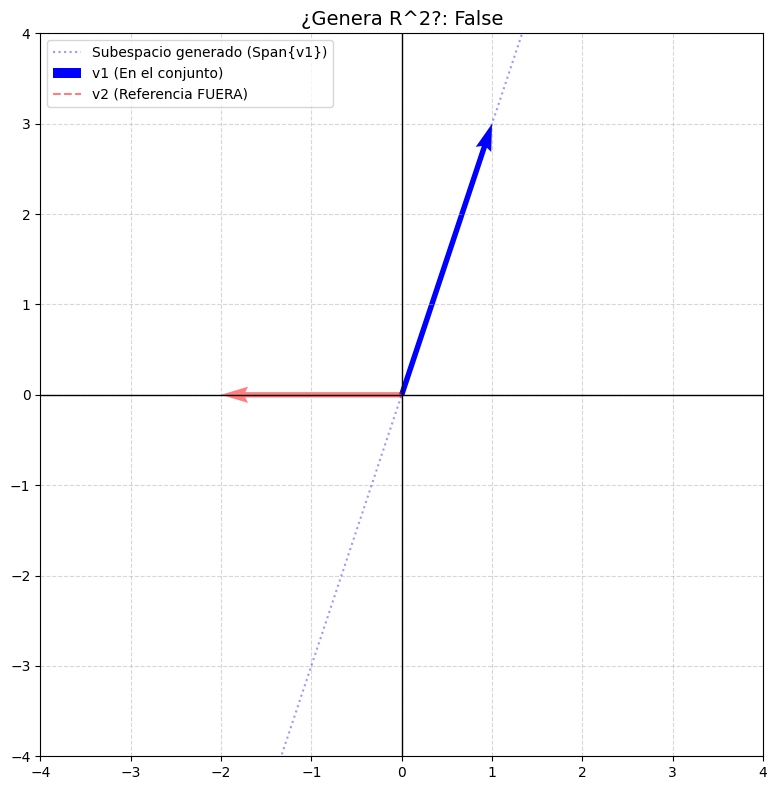

In [8]:
# ==========================================
# 1. Visualización con MATPLOTLIB (CORREGIDO)
# ==========================================
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Configuración básica
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

# --- Graficar elementos ---

# 1. El Span (Línea punteada) - Esto suele funcionar bien
plt.plot(span_x, span_y, color=v1_color, linestyle=':', alpha=0.4, 
         label='Subespacio generado (Span{v1})')

# 2. Vector v1 (Sólido)
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, 
           color=v1_color, label='v1 (En el conjunto)')

# 3. Vector v2 (SOLUCIÓN AL ERROR: quitamos linestyle del quiver)
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, 
           color=v2_ref_color, alpha=0.5)

# 4. Línea "fantasma" para que la leyenda muestre v2 como discontinuo sin dar error
plt.plot([], [], color=v2_ref_color, linestyle='--', alpha=0.5, 
         label='v2 (Referencia FUERA)')

# Etiquetas y textos
plt.title(f'¿Genera R^2?: {resultado_generacion}', fontsize=14)
plt.legend(loc='upper left')

plt.tight_layout()

plt.savefig(r"C:\Users\marco\Downloads\2_parcial_visualizacion_matplotlib.png")
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# --- Configuración de los vectores ---
v1 = np.array([1, 3])
# El ejemplo de uso dado solo usa v1 para el cálculo de generación.
# v2 se ignora para la lógica de "generar R2", pero lo graficaremos como referencia.
v2 = np.array([-2, 0])

# El conjunto "generador" proporcionado solo tiene un vector.
# Usamos tuplas porque los ndarrays no son hashables en sets.
conjunto_input = {tuple(v1)} 

# Función auxiliar de lógica (del prompt anterior, simplificada)
def genera_r2(vectores_set):
    # Convertimos el set de tuplas a una matriz de numpy
    matriz = np.array(list(vectores_set))
    # Un conjunto no puede generar R2 si tiene menos de 2 vectores
    if matriz.shape[0] < 2:
        return False
    # El rango debe ser 2 para independencia lineal en 2D
    return np.linalg.matrix_rank(matriz) == 2

# Resultado para el título/leyenda
resultado_generacion = genera_r2(conjunto_input)
print(f"¿Genera R^2?: {resultado_generacion}")

# --- Parámetros Visuales Comunes ---
limit = 4
v1_color = 'blue'
span_color = 'rgba(0, 0, 255, 0.1)' # Azul muy transparente para Plotly
v2_ref_color = 'red'

# ==========================================
# 1. Visualización con MATPLOTLIB
# ==========================================
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Configuración de ejes
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.axhline(0, color='black',linewidth=1)
ax.axvline(0, color='black',linewidth=1)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

# Título y etiquetas
titulo_mat = f'¿Genera $\\mathbb{{R}}^2$? {resultado_generacion}\n' \
             f'Conjunto: {{v1={tuple(v1)}}}'
plt.title(titulo_mat, fontsize=14, fontweight='bold')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')

# --- Graficar elementos ---

# 1. El Span (Generado) por el ÚNICO vector en el conjunto {v1}
# Esto es una línea infinita. La simulamos graficando una línea larga.
t = np.linspace(-limit*2, limit*2, 100)
span_x = t * v1[0]
span_y = t * v1[1]
plt.plot(span_x, span_y, color=v1_color, linestyle=':', alpha=0.4, 
         label='Subespacio generado (Span{v1})')

# 2. El Vector Principal v1 (origen a v1)
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, 
           color=v1_color, label='v1 (Único vector en el conjunto)')

# 3. Vector de Referencia v2 (para mostrar qué está FUERA del Span)
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, 
           color=v2_ref_color, linestyle='--', alpha=0.5, 
           label='v2 (Vector de referencia FUERA del conjunto)')

# Añadir etiquetas de texto a los vectores
plt.text(v1[0] + 0.1, v1[1] + 0.1, f'v1 {tuple(v1)}', color=v1_color, fontweight='bold')
plt.text(v2[0] - 0.5, v2[1] + 0.1, f'v2 {tuple(v2)}', color=v2_ref_color, alpha=0.7)

# Leyenda
plt.legend(loc='upper left', fontsize=9)

# Mostrar Matplotlib
plt.tight_layout()
plt.show()


¿Genera R^2?: False


ValueError: At least one value in the dash list must be positive

<Figure size 800x800 with 1 Axes>

In [10]:


# ==========================================
# 2. Visualización con PLOTLY
# ==========================================

# Datos para el Span (la línea infinita de v1)
t_plotly = np.linspace(-limit*3, limit*3, 2) # Solo necesitamos 2 puntos para una línea recta
span_plotly_x = t_plotly * v1[0]
span_plotly_y = t_plotly * v1[1]

fig = go.Figure()

# --- Capas de la visualización ---

# 1. El Span (Línea discontinua)
fig.add_trace(go.Scatter(
    x=span_plotly_x, 
    y=span_plotly_y,
    mode='lines',
    line=dict(color=v1_color, width=2, dash='dot'),
    name='Subespacio generado (Span{v1})',
    opacity=0.4,
    showlegend=True
))

# 2. Vector v1 (como flecha)
# Plotly no tiene quiver nativo simple, usamos scatter + annotations
fig.add_trace(go.Scatter(
    x=[0, v1[0]],
    y=[0, v1[1]],
    mode='lines+markers+text',
    line=dict(color=v1_color, width=4),
    marker=dict(size=12, symbol='triangle-up', angleref='previous'),
    text=['', f'<b>v1 {tuple(v1)}</b>'],
    textposition='top right',
    name='v1 (En el conjunto)',
    showlegend=True
))

# 3. Vector v2 (como flecha de referencia)
fig.add_trace(go.Scatter(
    x=[0, v2[0]],
    y=[0, v2[1]],
    mode='lines+markers+text',
    line=dict(color=v2_ref_color, width=2, dash='dash'),
    marker=dict(size=10, symbol='triangle-up', angleref='previous'),
    text=['', f'v2 {tuple(v2)}'],
    textposition='bottom left',
    name='v2 (Referencia FUERA)',
    opacity=0.6,
    showlegend=True
))

# --- Configuración del Diseño ---

titulo_plotly = (
    f"<b>¿Genera R^2? {resultado_generacion}</b><br>"
    f"<sup>Un solo vector v1={tuple(v1)} solo genera una línea, no el plano.</sup>"
)

fig.update_layout(
    title=titulo_plotly,
    xaxis=dict(title='Eje X', range=[-limit, limit], zeroline=True, zerolinecolor='black', gridcolor='lightgray'),
    yaxis=dict(title='Eje Y', range=[-limit, limit], zeroline=True, zerolinecolor='black', gridcolor='lightgray', scaleanchor="x", scaleratio=1),
    width=700,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor="rgba(255, 255, 255, 0.7)")
)

# Flecha de anotación extra para v1 (mejor estética de flecha)
fig.add_annotation(
    x=v1[0], y=v1[1],
    ax=0, ay=0,
    xref="x", yref="y",
    axref="x", ayref="y",
    showarrow=True,
    arrowhead=3,
    arrowsize=1,
    arrowwidth=3,
    arrowcolor=v1_color
)

# Flecha de anotación extra para v2
fig.add_annotation(
    x=v2[0], y=v2[1],
    ax=0, ay=0,
    xref="x", yref="y",
    axref="x", ayref="y",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor=v2_ref_color,
    opacity=0.6
)


# Mostrar Plotly
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\2_parcial_visualizacion_plotly.png")


### Explicación Visual

Ambos gráficos muestran lo mismo usando herramientas diferentes:

1.  **Vectores:** El vector principal $v_1=(1,3)$ es una flecha azul sólida. El vector de referencia $v_2=(-2,0)$, que NO está en el conjunto generador proporcionado, se muestra como una flecha roja discontinua.
2.  **El "Span" (Línea punteada azul):** Esta línea representa el subespacio generado por el *conjunto* $\{v_1\}$. Es la recta infinita que contiene a todos los múltiplos escalares de $v_1$ ($c \cdot v_1$).
3.  **¿Por qué NO genera $\mathbb{R}^2$?** $\mathbb{R}^2$ es todo el plano 2D (todo el fondo blanco del gráfico). Como puedes ver, hay infinitos puntos en el plano (incluido el extremo del vector rojo $v_2$) que **no están** sobre la línea punteada azul. Como el conjunto $\{v_1\}$ solo puede alcanzar puntos sobre esa línea, no puede generar "todo el plano". Necesitarías un segundo vector que no esté sobre esa línea para "llenar" la segunda dimensión.

[Video asociado a este ejercicio sobre espacio generado](https://www.youtube.com/watch?v=eGJEu4olb4U) 

# Cómo determinar que un subconjunto del espacio es LI o LD  



# Cómo determinar que un conjunto de n-tuplas es LI o LD usando el escalonamiento de la matriz asociada. 



Aquí tienes una solución robusta utilizando **SymPy**. 

Para lograr el "paso a paso" con fracciones o enteros, no podemos usar la función directa `rref()`, ya que esta da el resultado final. 

En su lugar, he programado un algoritmo de eliminación gaussiana manual que registra cada operación elemental.



# Función de Python con SymPy


In [2]:
import sympy as sp

def verificar_independencia_lineal(vectores):
    """
    Recibe una lista de listas/tuplas (vectores de R^m).
    Realiza el escalonamiento paso a paso y determina si son L.I.
    """
    # Crear la matriz cuyas columnas son los vectores dados
    A = sp.Matrix(vectores).T
    m, n = A.shape
    pasos = [A.copy()]
    
    print(f"--- Matriz Inicial ({m}x{n}) ---")
    sp.pprint(A)
    print("\nIniciando proceso de escalonamiento...\n")

    pivot_row = 0
    pivotes_encontrados = 0

    for j in range(n):  # Recorrer columnas
        if pivot_row >= m:
            break
            
        # 1. Buscar el primer elemento no nulo en la columna actual (debajo de la fila actual)
        pivot_idx = -1
        for i in range(pivot_row, m):
            if A[i, j] != 0:
                pivot_idx = i
                break
        
        if pivot_idx != -1:
            pivotes_encontrados += 1
            # Intercambio de filas si es necesario
            if pivot_idx != pivot_row:
                A.row_swap(pivot_row, pivot_idx)
                print(f"Paso: Intercambiar fila {pivot_row + 1} con fila {pivot_idx + 1}")
                sp.pprint(A)
                print()

            # 2. Hacer ceros debajo del pivote
            for i in range(pivot_row + 1, m):
                if A[i, j] != 0:
                    factor = A[i, j] / A[pivot_row, j]
                    # Operación elemental: Fi = Fi - factor * F_pivot
                    A.row_op(i, lambda v, k: v - factor * A[pivot_row, k])
                    print(f"Paso: Fila {i + 1} = Fila {i + 1} - ({factor}) * Fila {pivot_row + 1}")
                    sp.pprint(A)
                    print()
            
            pivot_row += 1
        else:
            print(f"Columna {j + 1} no tiene pivote disponible. Saltando...\n")

    # --- Resultado Final ---
    print("-" * 30)
    print("Matriz escalonada final:")
    sp.pprint(A)
    print(f"\nNúmero de vectores originales (n): {n}")
    print(f"Número de pivotes encontrados: {pivotes_encontrados}")

    if pivotes_encontrados == n:
        print("\nRESULTADO: Los vectores son LINEALMENTE INDEPENDIENTES.")
        print("Razón: Hay un pivote por cada columna (rango = n).")
    else:
        print("\nRESULTADO: Los vectores son LINEALMENTE DEPENDIENTES.")
        print(f"Razón: Solo se encontraron {pivotes_encontrados} pivotes para {n} vectores.")


In [4]:

# --- Ejemplo de uso ---
# Definimos 3 vectores en R^3
v1 = [2, -1, 3]
v2 = [3, 4, 1]
v3 = [2, -3, 4]

verificar_independencia_lineal([v1, v2, v3])


--- Matriz Inicial (3x3) ---
⎡2   3  2 ⎤
⎢         ⎥
⎢-1  4  -3⎥
⎢         ⎥
⎣3   1  4 ⎦

Iniciando proceso de escalonamiento...

Paso: Fila 2 = Fila 2 - (-1/2) * Fila 1
⎡2   3    2 ⎤
⎢           ⎥
⎢0  11/2  -2⎥
⎢           ⎥
⎣3   1    4 ⎦

Paso: Fila 3 = Fila 3 - (3/2) * Fila 1
⎡2   3    2 ⎤
⎢           ⎥
⎢0  11/2  -2⎥
⎢           ⎥
⎣0  -7/2  1 ⎦

Paso: Fila 3 = Fila 3 - (-7/11) * Fila 2
⎡2   3      2  ⎤
⎢              ⎥
⎢0  11/2   -2  ⎥
⎢              ⎥
⎣0   0    -3/11⎦

------------------------------
Matriz escalonada final:
⎡2   3      2  ⎤
⎢              ⎥
⎢0  11/2   -2  ⎥
⎢              ⎥
⎣0   0    -3/11⎦

Número de vectores originales (n): 3
Número de pivotes encontrados: 3

RESULTADO: Los vectores son LINEALMENTE INDEPENDIENTES.
Razón: Hay un pivote por cada columna (rango = n).



### ¿Cómo funciona el código?



1.  **Construcción**: La matriz se crea transponiendo los vectores (`.T`), ya que usualmente los recibimos como filas pero para la prueba de independencia deben ser las **columnas** de $A$.
2.  **Uso de SymPy**: Al inicializar con `sp.Matrix`, SymPy detecta si los números son enteros y, al realizar divisiones, automáticamente los convierte en objetos `Rational` (fracciones). Esto evita errores de precisión de punto flotante y mantiene la estética matemática.
3.  **Lógica de Escalonamiento**:
    * Utiliza `row_swap` para posicionar pivotes.
    * Utiliza `row_op` para realizar la eliminación hacia adelante (hacer ceros abajo).
4.  **Criterio de Independencia**: 
    * Si el número de pivotes es igual al número de vectores ($n$), el sistema homogéneo $Ax = 0$ solo tiene la solución trivial, por lo tanto, son **Linealmente Independientes**.
    * Si hay menos pivotes que vectores, existe al menos una variable libre, lo que implica **Dependencia Lineal**.





### Consideraciones Matemáticas
Recuerda que para que un conjunto de vectores sea linealmente independiente en $\mathbb{R}^m$:
* El número de vectores $n$ no puede ser mayor que la dimensión $m$ ($n \leq m$). Si $n > m$, el código detectará automáticamente que son dependientes porque no habrá suficientes filas para albergar $n$ pivotes.
* En la matriz escalonada, cada columna debe poseer una "entrada principal" o pivote.

In [ ]:
# ---Punto 6
# Definimos 3 vectores en R^3
v1 = [3, 1, 4, 1]
v2 = [1, 1, 0, 0] 
v3 = [0, 0, 2, 2]


verificar_independencia_lineal([v1, v2, v3])


--- Matriz Inicial (4x3) ---
⎡3  1  0⎤
⎢       ⎥
⎢1  1  0⎥
⎢       ⎥
⎢4  0  2⎥
⎢       ⎥
⎣1  0  2⎦

Iniciando proceso de escalonamiento...

Paso: Fila 2 = Fila 2 - (1/3) * Fila 1
⎡3   1   0⎤
⎢         ⎥
⎢0  2/3  0⎥
⎢         ⎥
⎢4   0   2⎥
⎢         ⎥
⎣1   0   2⎦

Paso: Fila 3 = Fila 3 - (4/3) * Fila 1
⎡3   1    0⎤
⎢          ⎥
⎢0  2/3   0⎥
⎢          ⎥
⎢0  -4/3  2⎥
⎢          ⎥
⎣1   0    2⎦

Paso: Fila 4 = Fila 4 - (1/3) * Fila 1
⎡3   1    0⎤
⎢          ⎥
⎢0  2/3   0⎥
⎢          ⎥
⎢0  -4/3  2⎥
⎢          ⎥
⎣0  -1/3  2⎦

Paso: Fila 3 = Fila 3 - (-2) * Fila 2
⎡3   1    0⎤
⎢          ⎥
⎢0  2/3   0⎥
⎢          ⎥
⎢0   0    2⎥
⎢          ⎥
⎣0  -1/3  2⎦

Paso: Fila 4 = Fila 4 - (-1/2) * Fila 2
⎡3   1   0⎤
⎢         ⎥
⎢0  2/3  0⎥
⎢         ⎥
⎢0   0   2⎥
⎢         ⎥
⎣0   0   2⎦

Paso: Fila 4 = Fila 4 - (1) * Fila 3
⎡3   1   0⎤
⎢         ⎥
⎢0  2/3  0⎥
⎢         ⎥
⎢0   0   2⎥
⎢         ⎥
⎣0   0   0⎦

------------------------------
Matriz escalonada final:
⎡3   1   0⎤
⎢         ⎥
⎢0  2/3  0⎥
⎢    

In [7]:
# ---Punto 6
# Definimos 3 vectores en R^3
v1 = [3, 0, 2, -2]
v2 = [5, 0, 3, -1] 
v3 = [1, -2, 1, 1]
v4 = [0, 4, -1, 1] 

verificar_independencia_lineal([v1, v2, v3, v4])


--- Matriz Inicial (4x4) ---
⎡3   5   1   0 ⎤
⎢              ⎥
⎢0   0   -2  4 ⎥
⎢              ⎥
⎢2   3   1   -1⎥
⎢              ⎥
⎣-2  -1  1   1 ⎦

Iniciando proceso de escalonamiento...

Paso: Fila 3 = Fila 3 - (2/3) * Fila 1
⎡3    5     1   0 ⎤
⎢                 ⎥
⎢0    0    -2   4 ⎥
⎢                 ⎥
⎢0   -1/3  1/3  -1⎥
⎢                 ⎥
⎣-2   -1    1   1 ⎦

Paso: Fila 4 = Fila 4 - (-2/3) * Fila 1
⎡3   5     1   0 ⎤
⎢                ⎥
⎢0   0    -2   4 ⎥
⎢                ⎥
⎢0  -1/3  1/3  -1⎥
⎢                ⎥
⎣0  7/3   5/3  1 ⎦

Paso: Intercambiar fila 2 con fila 3
⎡3   5     1   0 ⎤
⎢                ⎥
⎢0  -1/3  1/3  -1⎥
⎢                ⎥
⎢0   0    -2   4 ⎥
⎢                ⎥
⎣0  7/3   5/3  1 ⎦

Paso: Fila 4 = Fila 4 - (-7) * Fila 2
⎡3   5     1   0 ⎤
⎢                ⎥
⎢0  -1/3  1/3  -1⎥
⎢                ⎥
⎢0   0    -2   4 ⎥
⎢                ⎥
⎣0   0     4   -6⎦

Paso: Fila 4 = Fila 4 - (-2) * Fila 3
⎡3   5     1   0 ⎤
⎢                ⎥
⎢0  -1/3  1/3  -1⎥
⎢                ⎥


In [8]:
# Punto 8  

v1 = [1, 1, 1] 
v2 = [2, -1, 3]  
v3 = [-1, 5, -3] 
v4 = [0, 4, -1, 1] 

verificar_independencia_lineal([v1, v2, v3])


--- Matriz Inicial (3x3) ---
⎡1  2   -1⎤
⎢         ⎥
⎢1  -1  5 ⎥
⎢         ⎥
⎣1  3   -3⎦

Iniciando proceso de escalonamiento...

Paso: Fila 2 = Fila 2 - (1) * Fila 1
⎡1  2   -1⎤
⎢         ⎥
⎢0  -3  6 ⎥
⎢         ⎥
⎣1  3   -3⎦

Paso: Fila 3 = Fila 3 - (1) * Fila 1
⎡1  2   -1⎤
⎢         ⎥
⎢0  -3  6 ⎥
⎢         ⎥
⎣0  1   -2⎦

Paso: Fila 3 = Fila 3 - (-1/3) * Fila 2
⎡1  2   -1⎤
⎢         ⎥
⎢0  -3  6 ⎥
⎢         ⎥
⎣0  0   0 ⎦

Columna 3 no tiene pivote disponible. Saltando...

------------------------------
Matriz escalonada final:
⎡1  2   -1⎤
⎢         ⎥
⎢0  -3  6 ⎥
⎢         ⎥
⎣0  0   0 ⎦

Número de vectores originales (n): 3
Número de pivotes encontrados: 2

RESULTADO: Los vectores son LINEALMENTE DEPENDIENTES.
Razón: Solo se encontraron 2 pivotes para 3 vectores.


In [9]:
# Punto 9  

v1 = [1, 1, 0, 0] 
v2 = [0, 0, 1, 1]   
v3 = [-2, -2, 3, 3] 

verificar_independencia_lineal([v1, v2, v3])


--- Matriz Inicial (4x3) ---
⎡1  0  -2⎤
⎢        ⎥
⎢1  0  -2⎥
⎢        ⎥
⎢0  1  3 ⎥
⎢        ⎥
⎣0  1  3 ⎦

Iniciando proceso de escalonamiento...

Paso: Fila 2 = Fila 2 - (1) * Fila 1
⎡1  0  -2⎤
⎢        ⎥
⎢0  0  0 ⎥
⎢        ⎥
⎢0  1  3 ⎥
⎢        ⎥
⎣0  1  3 ⎦

Paso: Intercambiar fila 2 con fila 3
⎡1  0  -2⎤
⎢        ⎥
⎢0  1  3 ⎥
⎢        ⎥
⎢0  0  0 ⎥
⎢        ⎥
⎣0  1  3 ⎦

Paso: Fila 4 = Fila 4 - (1) * Fila 2
⎡1  0  -2⎤
⎢        ⎥
⎢0  1  3 ⎥
⎢        ⎥
⎢0  0  0 ⎥
⎢        ⎥
⎣0  0  0 ⎦

Columna 3 no tiene pivote disponible. Saltando...

------------------------------
Matriz escalonada final:
⎡1  0  -2⎤
⎢        ⎥
⎢0  1  3 ⎥
⎢        ⎥
⎢0  0  0 ⎥
⎢        ⎥
⎣0  0  0 ⎦

Número de vectores originales (n): 3
Número de pivotes encontrados: 2

RESULTADO: Los vectores son LINEALMENTE DEPENDIENTES.
Razón: Solo se encontraron 2 pivotes para 3 vectores.



# Diseño del Segundo Parcial – Álgebra Lineal

**Programa:** Ingeniería Agropecuaria – UdeA Campus Caucasia
**Parcial:** 2
**Fecha:** martes **24 de marzo**
**Duración:** 2 horas
**Modalidad:** Individual, escrita
**Ponderación sugerida:** 20 % del curso

---



# Unidades evaluadas

**Capítulo 2 y parte inicial del Capítulo 3**

* **Capítulo 2 – Ortogonalidad**

  * Bases ortonormales y proyección en (\mathbb{R}^n)
  * Método de mínimos cuadrados
  * Espacios con producto interno

* **Capítulo 3 – Transformaciones Lineales**

  * Definición, ejemplos y álgebra de transformaciones lineales
  * Núcleo e imagen

---



## Objetivo del parcial

Evaluar la capacidad del estudiante para **analizar estructuras con producto interno**, aplicar **proyecciones y mínimos cuadrados**, y **comprender las transformaciones lineales** como modelos matemáticos fundamentales en problemas de la ingeniería agropecuaria y la ciencia de datos.

---



# Competencias evaluadas

* Maneja correctamente productos internos y normas
* Construye e interpreta proyecciones ortogonales
* Aplica el método de mínimos cuadrados
* Identifica y analiza núcleo e imagen de una transformación lineal
* Conecta estos conceptos con modelos de regresión y análisis de datos

---



## 📊 Estructura del parcial (4 puntos)

| Punto     | Tipo                 | Contenidos                                 | %         |
| --------- | -------------------- | ------------------------------------------ | --------- |
| 1         | Conceptual–operativo | Producto interno y ortogonalidad           | 25 %      |
| 2         | Procedimental        | Proyección ortogonal y mínimos cuadrados   | 25 %      |
| 3         | Estructural          | Transformaciones lineales, núcleo e imagen | 25 %      |
| 4         | Aplicado             | Ciencia de datos agropecuarios con Python  | 25 %      |
| **Total** |                      |                                            | **100 %** |

---



## Desarrollo sugerido del parcial

### **Punto 1 – Producto interno y ortogonalidad (25 %)**

Sea $V = \mathbb{R}^3$ con el producto interno usual.

a) Verifique que un conjunto de vectores asociados a mediciones agroclimáticas es ortogonal.
b) Normalice dichos vectores y construya una base ortonormal.
c) Explique por qué las bases ortonormales son relevantes en el análisis de datos agrícolas.

- *Se evalúa:* dominio conceptual, cálculo y argumentación.



### **Punto 2 – Proyección y mínimos cuadrados (25 %)**

Un conjunto de datos experimentales relaciona la fertilización con el rendimiento de un cultivo.

a) Modele el problema como uno de aproximación por mínimos cuadrados.
b) Calcule la proyección ortogonal de un vector de observaciones sobre un subespacio generado.
c) Interprete el resultado en términos de error y ajuste del modelo.

- *Se evalúa:* modelación matemática e interpretación.

---



### **Punto 3 – Transformaciones lineales (25 %)**

Sea $T: \mathbb{R}^3 \to \mathbb{R}^2$ una transformación que modela la reducción de variables agrícolas.

a) Verifique que $T$ es una transformación lineal.
b) Determine el núcleo y la imagen de $T$.
c) Interprete el significado del núcleo en términos de pérdida de información.

- *Se evalúa:* análisis estructural y comprensión geométrica.

---



### **Punto 4 – Aplicación a ciencia de datos con Python (25 %)**

En el preprocesamiento de datos agrícolas se utilizan transformaciones lineales y proyecciones.

a) Explique cómo la proyección ortogonal se relaciona con la regresión lineal en Python.
b) Describa el papel del núcleo de una transformación en la reducción de dimensionalidad.
c) Relacione estos conceptos con el uso de librerías como `numpy` o `scikit-learn`.

- *Se evalúa:* conexión teoría–aplicación–pensamiento computacional.

---



## Criterios de evaluación

* Correcto uso de definiciones y propiedades
* Claridad y coherencia en los procedimientos
* Interpretación matemática en contexto agropecuario
* Capacidad de vincular álgebra lineal con ciencia de datos

---



## Observación pedagógica

Este parcial consolida el paso **del álgebra estructural al modelado**, preparando al estudiante para comprender **regresión, PCA y modelos lineales**, fundamentales en machine learning aplicado a la ingeniería agropecuaria.


